#### This is the RABI Oscillation Notebook

##### In this experiment we will use the Pulseblaster, AOM, RF Switch and the Windfreak
##### The pulseblaster outputs should be connected as listed below:
###### 1. Output 0: Connect to AOM
###### 2. Output 1: Connect to Lock-in AMP REF IN input
###### 3. Output 23: Connect to the RF Switch TTL input

In [7]:
from Ametek_5210 import Ametek5210
from pulseblaster_d import pulseblasterd
from windfreak import windfreak

In [8]:
import numpy as np
import time
import datetime
import matplotlib.pyplot as plt
import csv

In [ ]:
#initalize equiptment
pulser = pulseblasterd('pb')
rf = windfreak('windfreak', 'COM5')
lockin = Ametek5210('lockin', 'GPIB0::12::INSTR')

In [ ]:
# This function determines the delay based on the tc of the lock in amp
def set_delay(lockin_tc):
    timeconst = {0: '1 ms',
    1: '3 ms',
    2: '10 ms',
    3: '30 ms' ,
    4: '100 ms',
    5: '300 ms',
    6: '1 s',
    7: '3 s',
    8: '10 s',
    9: '30 s',
    10: '100 s',
    11: '300 s',
    12: '1 ks',
    13: '3 ks'}

    timeconst_bw = {'1 ms' :0,
    '3 ms': 1,
    '10 ms': 2,
    '30 ms': 3 ,
    '100 ms': 4,
    '300 ms' : 5,
    '1 s' : 6,
    '3 s' : 7,
    '10 s': 8,
    '30 s': 9,
    '100 s': 10,
    '300 s': 11,
    '1 ks' : 12,
    '3 ks' : 13}

    tc_s = {0: 0.001,  #get timeconstant in secs
    1: 0.003,
    2: 0.01,
    3: 0.03 ,
    4: 0.1,
    5: 0.3,
    6: 1,
    7: 3,
    8: 10,
    9: 30,
    10: 100,
    11: 300,
    12: 1000,
    13: 3000}

    val = timeconst_bw[lockin_tc]
    if(type(val) != int):
        return "Error: invalid input!"
    else:
        return 5* tc_s[val]
    

#### The Rabi Oscillation experiment is implemented below:
#### 1. Make sure all the equipment is turned on
#### 2. There are some parameters in the beginning you can set to see how the results change based on the values you set

##### If you run into any issues please let the TA know!

delay: 5
7.899999999999997e-07
37
3149.0
3457.0
3496.0
3386.0
3137.0
3122.0
2614.0
2668.0
2701.0
3062.0
3155.0
3370.0
3321.0
3268.0
3112.0
3127.0
2888.0
2902.0
3000.0
3127.0
2949.0
3314.0
3189.0
3338.0
3176.0
3116.0
3024.0
2989.0
3042.0
3033.0
3037.0
3328.0
3263.0
3254.0
3246.0
3238.0
3160.0


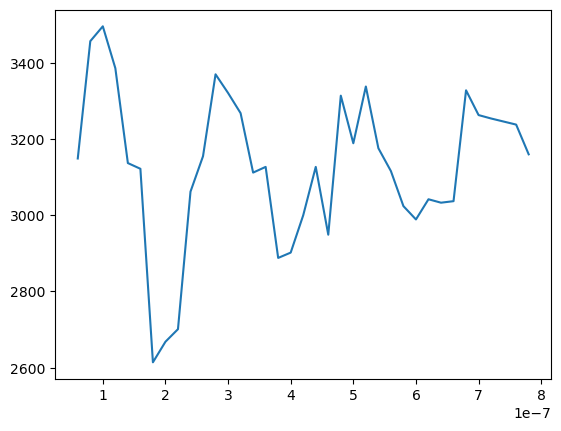

In [10]:
#TODO: set below parameters
rf_power =  #in dBm, do not exceed -10dBm (try -30 to -10 dBm)
rf_freq =  #determined by the PulesdODMR or CWODMR (in MHz)

start_width = .06e-6 #set the shortest RF pulse length
end_width = 0.8e-6 #set the longest RF pulse length
width_step = .02e-6 #set the RF step size
rf_width = np.arange(start_width, end_width, width_step)

pulser._set_rf_width(0)
#set aom pulse length (optional- default is 5 microseconds)
pulser._set_aom_width(5e-6)

#create array of outputs from the lockin amp
vals = np.zeros(len(rf_width))

#turn on the RF module to the right frequency
rf.set_channel(0)
rf.set_power_dBm(rf_power) #-30 with amp, no more than -5dBm!
rf.set_freq(rf_freq)
#turn on windfreak
rf.on()

tc = '1 s' #use '300 ms' to get data faster, longer times for less noise

#set the sensitivity and the time constant of the lock in amp

lockin.sensitivity('10 mV') #or 30mV
time. sleep(1)
lockin.time_constant(tc) #1s


#set the delay based on the lockin sensitivity
delay = set_delay(tc)
print("delay: " + str(delay))

#set the width of the lock in pulse
pulser._set_lock_in_width(2.5e-3)
print(str(pulser._set_rf_width()))
num = len(rf_width)
print(num)

for i in range(num):
    pulser._set_rf_width(rf_width[i])
    pulser.program_pulsedstateV2(rf_width[num-1])
    pulser.start()
    time.sleep(delay)
    val = lockin.magnitude()
    vals[i] = val
    print(val)
    pulser.stop()

rf.off()

plt.plot(rf_width, vals)
plt.show()

In [20]:
#write data to a csv file to save the data

dt = str(datetime.datetime.now()).strip().replace(' ', '-').replace('.','-').replace(':',"-")
filename = "Rabi" + dt + ".csv"
header = ['rf_frequency(MHz)', 'Lock in amp mag']
with open(filename, 'w', newline='') as csvfile:
    csvwriter = csv.writer(csvfile)
    csvwriter.writerow(header)
    for i in range(len(vals)):
        row = [rf_width[i], vals[i]]
        print(row)
        csvwriter.writerow(row)

[6e-08, 3149.0]
[8e-08, 3457.0]
[1.0000000000000001e-07, 3496.0]
[1.2000000000000002e-07, 3386.0]
[1.4000000000000004e-07, 3137.0]
[1.6000000000000003e-07, 3122.0]
[1.8000000000000002e-07, 2614.0]
[2.0000000000000004e-07, 2668.0]
[2.2000000000000006e-07, 2701.0]
[2.400000000000001e-07, 3062.0]
[2.6000000000000005e-07, 3155.0]
[2.8000000000000007e-07, 3370.0]
[3.000000000000001e-07, 3321.0]
[3.200000000000001e-07, 3268.0]
[3.400000000000001e-07, 3112.0]
[3.600000000000001e-07, 3127.0]
[3.800000000000001e-07, 2888.0]
[4.0000000000000014e-07, 2902.0]
[4.2000000000000016e-07, 3000.0]
[4.4000000000000013e-07, 3127.0]
[4.6000000000000015e-07, 2949.0]
[4.800000000000002e-07, 3314.0]
[5.000000000000001e-07, 3189.0]
[5.200000000000001e-07, 3338.0]
[5.400000000000001e-07, 3176.0]
[5.600000000000001e-07, 3116.0]
[5.800000000000002e-07, 3024.0]
[6.000000000000002e-07, 2989.0]
[6.200000000000001e-07, 3042.0]
[6.400000000000001e-07, 3033.0]
[6.600000000000001e-07, 3037.0]
[6.800000000000002e-07, 332

### RABI FITTING CODE

In [12]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


In [25]:
filename = 'Rabi2024-04-25-15-08-03-458808.csv' #enter the file name & path(if it is not in the same folder) as a string

with open(filename, 'r') as f:
    reader = csv.reader(f)
    data = list(reader)

data_array = np.array(data)

rf_pulse_width = np.zeros(len(data_array)-1)
lock_in_mag = np.zeros(len(data_array)-1)
for i in range(len(data_array)):
    if i == 0:
        pass
    else:
        print(data_array[i])
        rf_pulse_width[i-1] = float(data_array[i][0])
        lock_in_mag[i-1] = float(data_array[i][1])


['6e-08' '3149.0']
['8e-08' '3457.0']
['1.0000000000000001e-07' '3496.0']
['1.2000000000000002e-07' '3386.0']
['1.4000000000000004e-07' '3137.0']
['1.6000000000000003e-07' '3122.0']
['1.8000000000000002e-07' '2614.0']
['2.0000000000000004e-07' '2668.0']
['2.2000000000000006e-07' '2701.0']
['2.400000000000001e-07' '3062.0']
['2.6000000000000005e-07' '3155.0']
['2.8000000000000007e-07' '3370.0']
['3.000000000000001e-07' '3321.0']
['3.200000000000001e-07' '3268.0']
['3.400000000000001e-07' '3112.0']
['3.600000000000001e-07' '3127.0']
['3.800000000000001e-07' '2888.0']
['4.0000000000000014e-07' '2902.0']
['4.2000000000000016e-07' '3000.0']
['4.4000000000000013e-07' '3127.0']
['4.6000000000000015e-07' '2949.0']
['4.800000000000002e-07' '3314.0']
['5.000000000000001e-07' '3189.0']
['5.200000000000001e-07' '3338.0']
['5.400000000000001e-07' '3176.0']
['5.600000000000001e-07' '3116.0']
['5.800000000000002e-07' '3024.0']
['6.000000000000002e-07' '2989.0']
['6.200000000000001e-07' '3042.0']
['6.

In [26]:
#TODO: set initial guesses for curve fitting
sinusoid_amp = 3000  #starting amp of signal
sinusoid_period = 2e-7 #time bewteen crests or troughs of the sine wave 
sinusoid_frequeny = 1/sinusoid_period
phi = 0

In [27]:
#curve fit a damped sine to the data

def sine(times, frequency, phi ):
    return np.sin(frequency*times+phi)
def exp(times, amplitude, lbda):
    return amplitude*np.exp(-lbda*times)

def damped_sin_func(times, amplitude, frequency, phi, ldba,shift):
    return exp(times, amplitude, ldba)*sine(times, frequency, phi)+shift
popt,pcov = curve_fit(damped_sin_func, #our function
                      rf_pulse_width, #measured x values
                      lock_in_mag, #measured y values
                      p0 = (140, (1/0.2e-6), 0.1e-6, -0.2, 850))

In [30]:
print(popt)

[-5.11103915e+02  3.06925490e+07 -4.60557601e+00  2.07838827e+06
  3.10473880e+03]


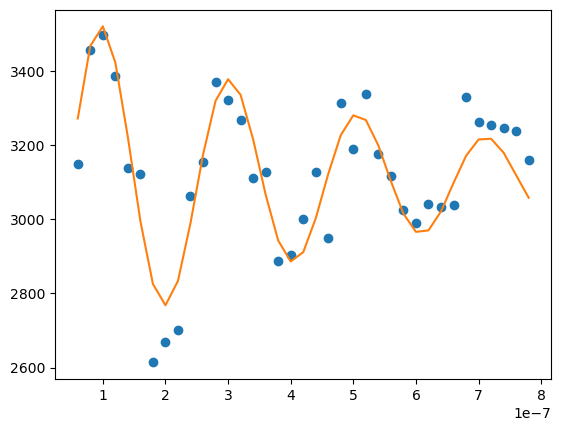

In [41]:
plt.plot(rf_pulse_width,lock_in_mag, 'o')
plt.plot(rf_pulse_width, damped_sin_func(rf_pulse_width, popt[0], popt[1], popt[2], popt[3], popt[4]))
plt.show()